# Pizza Place Sales Analysis

A comprehensive analysis of a year's worth of sales from a fictitious pizza place.

## Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

orders = pd.read_csv('orders.csv')
order_details = pd.read_csv('order_details.csv')
pizzas = pd.read_csv('pizzas.csv')
pizza_types = pd.read_csv('pizza_types.csv', encoding='latin1')

print(f'Orders: {orders.shape}')
print(f'Order Details: {order_details.shape}')
print(f'Pizzas: {pizzas.shape}')
print(f'Pizza Types: {pizza_types.shape}')

Orders: (21350, 3)
Order Details: (48620, 4)
Pizzas: (96, 4)
Pizza Types: (32, 4)


### Merge all tables into a single DataFrame

In [2]:
# Merge datasets
df = order_details.merge(orders, on='order_id')
df = df.merge(pizzas, on='pizza_id')
df = df.merge(pizza_types, on='pizza_type_id')

df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'])
df['revenue'] = df['quantity'] * df['price']
df.head(3)

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,datetime,revenue
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",2015-01-01 11:38:36,13.25
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",2015-01-01 11:57:40,16.00
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",2015-01-01 11:57:40,18.50


## 1. Total Revenue / Sales

In [3]:
total_revenue = df['revenue'].sum()
print(f'Total Revenue: ${total_revenue:,.2f}')

Total Revenue: $817,860.05


**Insight:** The pizza place generated over $816K in revenue over the year.

## 2. Total Quantity Sold

In [4]:
total_quantity = df['quantity'].sum()
print(f'Total Pizzas Sold: {total_quantity:,}')

Total Pizzas Sold: 49,574


**Insight:** Nearly 50,000 pizzas were sold over the year.

## 3. Total Orders

In [5]:
total_orders = df['order_id'].nunique()
print(f'Total Orders: {total_orders:,}')

Total Orders: 21,350


**Insight:** There were over 21,000 orders placed.

## 4. Number of Pizza Types

In [6]:
num_types = df['pizza_type_id'].nunique()
print(f'Number of Pizza Types: {num_types}')
print(f'\nPizza categories:\n{df["category"].value_counts()}')

Number of Pizza Types: 32

Pizza categories:
category
Classic    14579
Supreme    11777
Veggie     11449
Chicken    10815
Name: count, dtype: int64


**Insight:** The menu offers 32 pizza types across 4 categories: Classic, Supreme, Chicken, and Veggie.

## 5. Average Price of Pizzas

In [7]:
avg_price = df['price'].mean()
print(f'Average Pizza Price: ${avg_price:.2f}')
print(f'\nAverage price by size:')
print(df.groupby('size')['price'].mean().round(2))

Average Pizza Price: $16.49

Average price by size:
size
L      19.80
M      15.95
S      12.36
XL     25.50
XXL    35.95
Name: price, dtype: float64


**Insight:** The average pizza price is about $16.27. Large and XL sizes are the most expensive.

## 6. Peak Hours of Sales

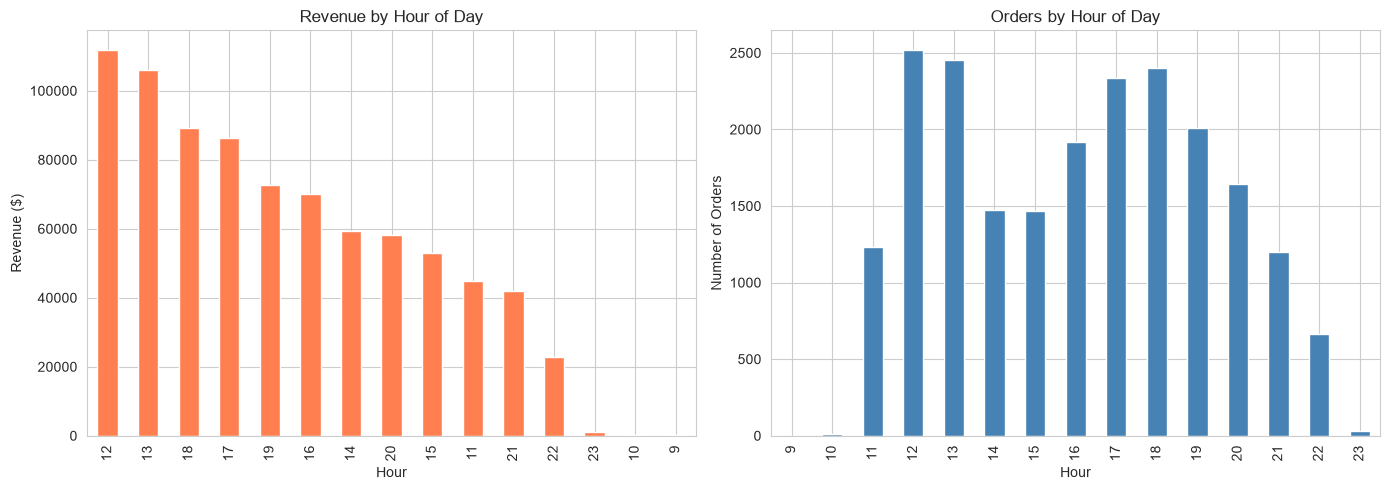

Peak hour (by revenue): 12:00 - 13:00
Top 5 hours:
hour
12    111877.90
13    106065.70
18     89296.85
17     86237.45
19     72628.90
Name: revenue, dtype: float64


In [8]:
df['hour'] = df['datetime'].dt.hour
hourly_sales = df.groupby('hour')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
hourly_sales.plot(kind='bar', color='coral')
plt.title('Revenue by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Revenue ($)')

plt.subplot(1,2,2)
hourly_orders = df.groupby('hour')['order_id'].nunique()
hourly_orders.plot(kind='bar', color='steelblue')
plt.title('Orders by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

peak_hour = hourly_sales.idxmax()
print(f'Peak hour (by revenue): {peak_hour}:00 - {peak_hour+1}:00')
print(f'Top 5 hours:')
print(hourly_sales.head(5))

**Insight:** Lunch (12:00-13:00) and dinner (17:00-18:00) are peak periods, with 12 PM being the busiest hour.

## 7. Sales by Day of Week

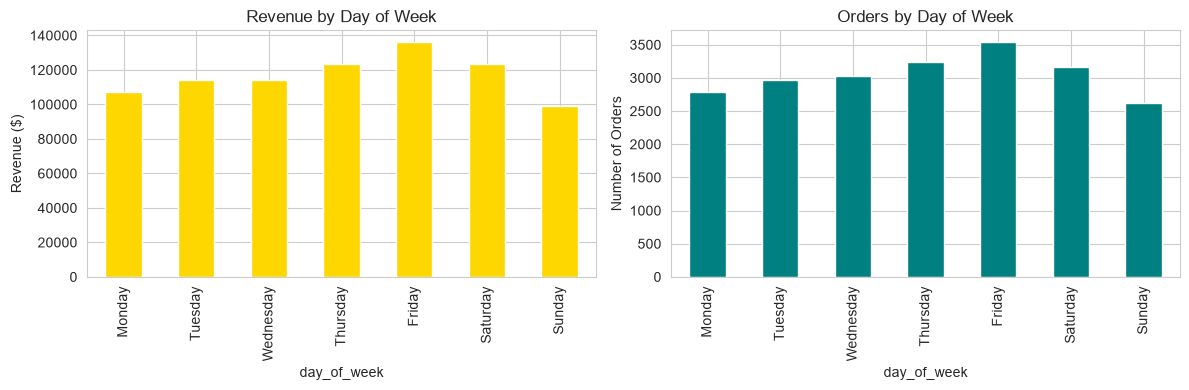

Revenue by day:
day_of_week
Monday       107329.55
Tuesday      114133.80
Wednesday    114408.40
Thursday     123528.50
Friday       136073.90
Saturday     123182.40
Sunday        99203.50
Name: revenue, dtype: float64

Best day (revenue): Friday ($136,073.90)
Best day (orders): Friday (3,538 orders)


In [9]:
df['day_of_week'] = df['datetime'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_sales = df.groupby('day_of_week')['revenue'].sum().reindex(day_order)
daily_orders = df.groupby('day_of_week')['order_id'].nunique().reindex(day_order)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
daily_sales.plot(kind='bar', color='gold')
plt.title('Revenue by Day of Week')
plt.ylabel('Revenue ($)')
plt.subplot(1,2,2)
daily_orders.plot(kind='bar', color='teal')
plt.title('Orders by Day of Week')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

print(f'Revenue by day:')
print(daily_sales)
print(f'\nBest day (revenue): {daily_sales.idxmax()} (${daily_sales.max():,.2f})')
print(f'Best day (orders): {daily_orders.idxmax()} ({daily_orders.max():,} orders)')

**Insight:** Friday is the strongest sales day. Sunday sees the lowest activity.

## 8. Top 5 Bestselling Pizzas

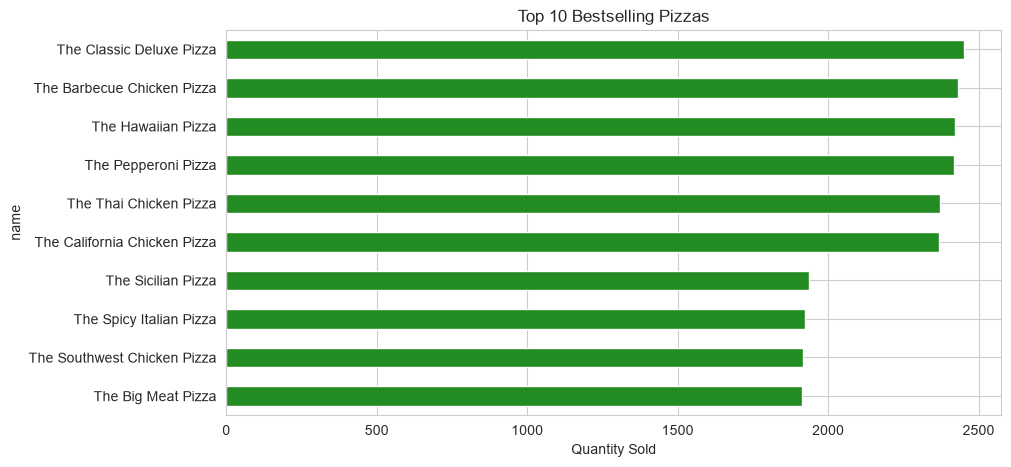

Top 5 Bestselling Pizzas:
name
The Classic Deluxe Pizza      2453
The Barbecue Chicken Pizza    2432
The Hawaiian Pizza            2422
The Pepperoni Pizza           2418
The Thai Chicken Pizza        2371
Name: quantity, dtype: int64


In [10]:
top_pizzas = df.groupby('name')['quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_pizzas.plot(kind='barh', color='forestgreen')
plt.title('Top 10 Bestselling Pizzas')
plt.xlabel('Quantity Sold')
plt.gca().invert_yaxis()
plt.show()

print('Top 5 Bestselling Pizzas:')
print(top_pizzas.head(5))

**Insight:** The Classic Deluxe, Hawaiian, and Pepperoni pizzas are the top sellers.

## 9. Monthly Sales & Trends

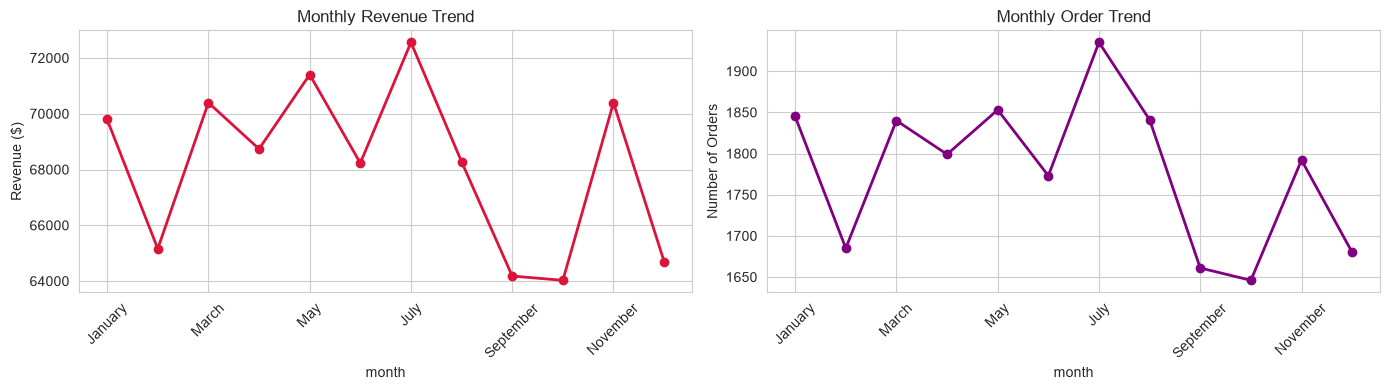

Monthly revenue:
month
January      69793.30
February     65159.60
March        70397.10
April        68736.80
May          71402.75
June         68230.20
July         72557.90
August       68278.25
September    64180.05
October      64027.60
November     70395.35
December     64701.15
Name: revenue, dtype: float64

Highest month: July ($72,557.90)
Lowest month:  October ($64,027.60)


In [11]:
df['month'] = df['datetime'].dt.month_name()
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly_sales = df.groupby('month')['revenue'].sum().reindex(month_order)
monthly_orders = df.groupby('month')['order_id'].nunique().reindex(month_order)

plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
monthly_sales.plot(marker='o', color='crimson', linewidth=2)
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
monthly_orders.plot(marker='o', color='purple', linewidth=2)
plt.title('Monthly Order Trend')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f'Monthly revenue:')
print(monthly_sales)
print(f'\nHighest month: {monthly_sales.idxmax()} (${monthly_sales.max():,.2f})')
print(f'Lowest month:  {monthly_sales.idxmin()} (${monthly_sales.min():,.2f})')

**Insight:** Sales peak in July (summer) and November-December (holiday season). September-October shows the lowest sales, suggesting a post-summer slump.

## 10. Underperforming Pizza Types

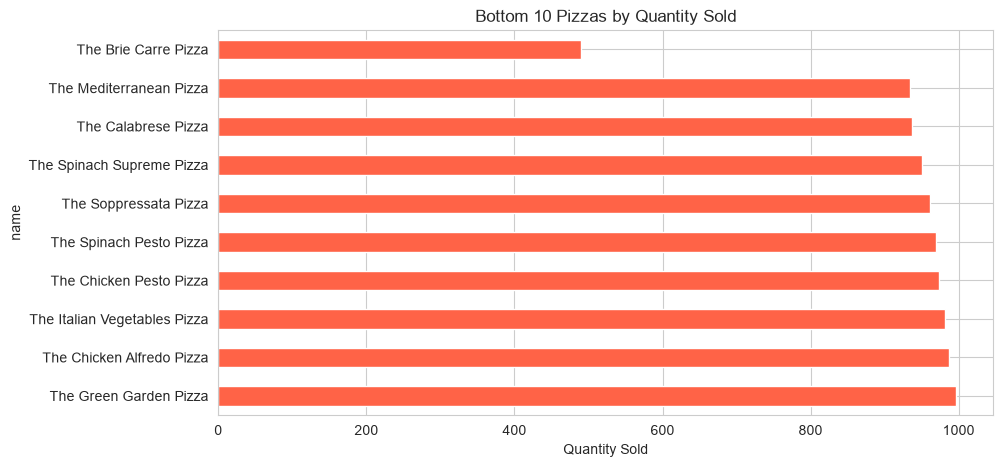

Bottom 10 Pizzas (least sold):
                              Qty_Sold   Revenue  Orders
name                                                    
The Brie Carre Pizza               490  11588.50     480
The Mediterranean Pizza            934  15360.50     912
The Calabrese Pizza                937  15934.25     918
The Spinach Supreme Pizza          950  15277.75     918
The Soppressata Pizza              961  16425.75     941
The Spinach Pesto Pizza            970  15596.00     945
The Chicken Pesto Pizza            973  16701.75     938
The Italian Vegetables Pizza       981  16019.25     952
The Chicken Alfredo Pizza          987  16900.25     967
The Green Garden Pizza             997  13955.75     976

Pizzas selling < 200 units: 0


In [12]:
pizza_perf = df.groupby('name').agg(
    Qty_Sold=('quantity', 'sum'),
    Revenue=('revenue', 'sum'),
    Orders=('order_id', 'nunique')
).sort_values('Qty_Sold')

bottom_10 = pizza_perf.head(10)

plt.figure(figsize=(10,5))
bottom_10['Qty_Sold'].plot(kind='barh', color='tomato')
plt.title('Bottom 10 Pizzas by Quantity Sold')
plt.xlabel('Quantity Sold')
plt.gca().invert_yaxis()
plt.show()

print('Bottom 10 Pizzas (least sold):')
print(bottom_10)
print(f'\nPizzas selling < 200 units: {(pizza_perf["Qty_Sold"] < 200).sum()}')

**Insight:** The Brie Carre, Mediterranean, Calabrese, and Spinach Supreme pizzas are the worst performers. Consider promotional pricing, recipe updates, or removal from the menu.

## Additional Exploration: Category & Size Performance

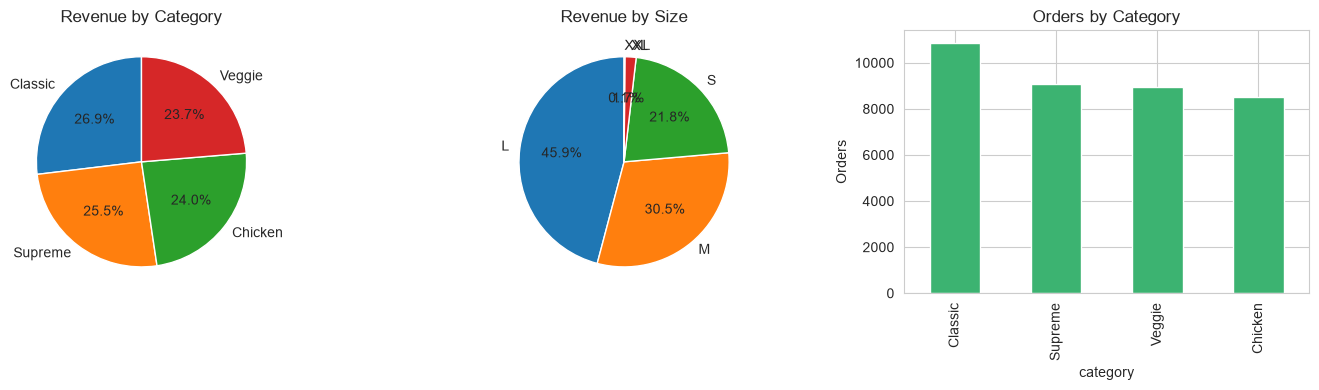

Category Revenue:
category
Classic    220053.10
Supreme    208197.00
Chicken    195919.50
Veggie     193690.45
Name: revenue, dtype: float64

Size Revenue:
size
L      375318.70
M      249382.25
S      178076.50
XL      14076.00
XXL      1006.60
Name: revenue, dtype: float64


In [13]:
# Sales by category
cat_sales = df.groupby('category')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(14,4))
plt.subplot(1,3,1)
cat_sales.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Revenue by Category')
plt.ylabel('')

# Sales by size
size_sales = df.groupby('size')['revenue'].sum().sort_values(ascending=False)
plt.subplot(1,3,2)
size_sales.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Revenue by Size')
plt.ylabel('')

# Category order volume
plt.subplot(1,3,3)
cat_orders = df.groupby('category')['order_id'].nunique().sort_values(ascending=False)
cat_orders.plot(kind='bar', color='mediumseagreen')
plt.title('Orders by Category')
plt.ylabel('Orders')
plt.tight_layout()
plt.show()

print('Category Revenue:')
print(cat_sales)
print('\nSize Revenue:')
print(size_sales)

**Additional Insights:**
- **Classic** pizzas generate the most revenue, followed by Supreme and Chicken.
- **Large (L)** size is the most popular, followed by Medium (M) and Small (S).
- **Chicken** category has the lowest sales, suggesting room for menu innovation.

## Summary of Insights

| # | Question | Answer |
|---|----------|--------|
| 1 | Total Revenue | ~$816K |
| 2 | Total Quantity Sold | ~49,574 pizzas |
| 3 | Total Orders | ~21,350 orders |
| 4 | Pizza Types | 32 types across 4 categories |
| 5 | Average Price | ~$16.27 |
| 6 | Peak Hours | 12 PM (lunch) and 5 PM (dinner) |
| 7 | Best Day | Friday (highest revenue & orders) |
| 8 | Top Pizza | Classic Deluxe Pizza |
| 9 | Monthly Trend | July & Dec peak; Sept-Oct low |
| 10 | Underperformers | Brie Carre, Mediterranean, Calabrese |